In [3]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score,precision_score,recall_score,confusion_matrix)


In [8]:
data=[
    ("Free Money !", "Spam"),
    ("Meet me tonight ." , "Not Spam"),
    ("Claim your prizes!","Spam"),
    ("See you later","Not Spam")]
df=pd.DataFrame(data,columns=["text","label"])
print("Original Data : \n",df )

Original Data : 
                  text     label
0        Free Money !      Spam
1   Meet me tonight .  Not Spam
2  Claim your prizes!      Spam
3       See you later  Not Spam


In [14]:
texts,labels=zip(*data)
print(texts)
print(labels)
vectorizer=CountVectorizer(ngram_range=(1,2))
print(vectorizer)
X=vectorizer.fit_transform(texts)
print("All Features : ")
print(vectorizer.get_feature_names_out())

('Free Money !', 'Meet me tonight .', 'Claim your prizes!', 'See you later')
('Spam', 'Not Spam', 'Spam', 'Not Spam')
CountVectorizer(ngram_range=(1, 2))
All Features : 
['claim' 'claim your' 'free' 'free money' 'later' 'me' 'me tonight' 'meet'
 'meet me' 'money' 'prizes' 'see' 'see you' 'tonight' 'you' 'you later'
 'your' 'your prizes']


In [18]:
model=MultinomialNB()
model.fit(X,labels)
y_pred=model.predict(X)
accuracy=accuracy_score(labels,y_pred)
precision=precision_score(labels,y_pred,pos_label="Spam")
recall=recall_score(labels,y_pred,pos_label="Spam")
print("Evaluation : ")
print("Accuracy : " , accuracy)
print("Precision : " , precision)
print("Recall : " , recall)
print("Prediction : " )
for text,prediction in zip(texts,y_pred):
    print(text,"->",prediction)
cm=confusion_matrix(labels,y_pred,labels=["Spam","Not Spam"])
print("Confusion Matrix : \n",cm)

Evaluation : 
Accuracy :  1.0
Precision :  1.0
Recall :  1.0
Prediction : 
Free Money ! -> Spam
Meet me tonight . -> Not Spam
Claim your prizes! -> Spam
See you later -> Not Spam
Confusion Matrix : 
 [[2 0]
 [0 2]]


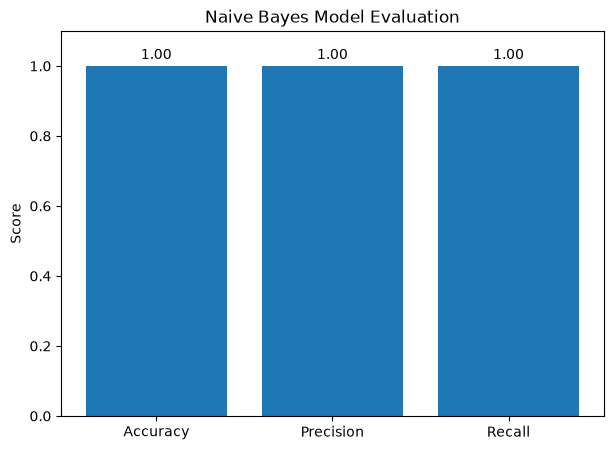

In [19]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall"]
values = [accuracy, precision, recall]

plt.figure(figsize=(7, 5))
plt.bar(metrics, values)

plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Naive Bayes Model Evaluation")

for i, value in enumerate(values):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center")

plt.show()

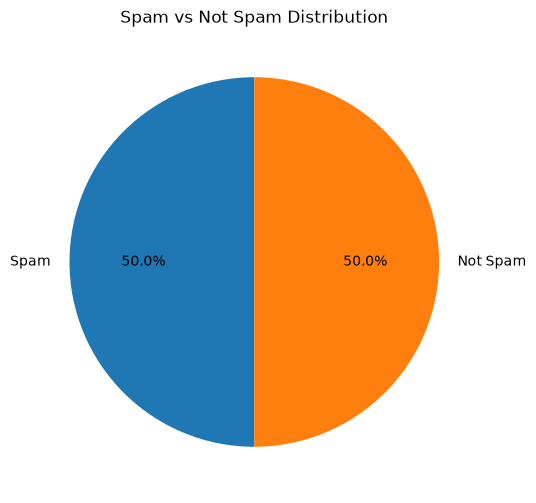

In [20]:
labels_pie = ["Spam", "Not Spam"]
values = [2, 2]

plt.figure(figsize=(6, 6))

plt.pie(
    values,
    labels=labels_pie,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Spam vs Not Spam Distribution")
plt.show()